In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
df = pd.read_csv('Iris.csv')

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df = df.iloc[:,1:]

In [5]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
encoder = LabelEncoder()

In [8]:
df['Species'] = encoder.fit_transform(df['Species'])

In [9]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [11]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

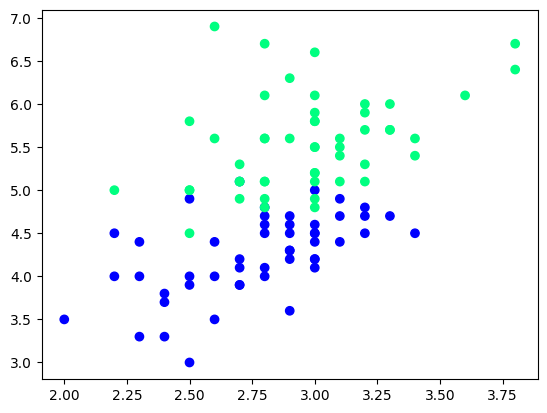

In [13]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [14]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
79,2.6,3.5,1
95,3.0,4.2,1
103,2.9,5.6,2
70,3.2,4.8,1
109,3.6,6.1,2
62,2.2,4.0,1
97,2.9,4.3,1
106,2.5,4.5,2
64,2.9,3.6,1
77,3.0,5.0,1


In [15]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [16]:
df_train

,SepalWidthCm,PetalLengthCm,Species
123,2.7,4.9,2
126,2.8,4.8,2
103,2.9,5.6,2
131,3.8,6.4,2
63,2.9,4.7,1
143,3.2,5.9,2
129,3.0,5.8,2
132,2.8,5.6,2
75,3.0,4.4,1
120,3.2,5.7,2


In [17]:
df_val

,SepalWidthCm,PetalLengthCm,Species
101,2.7,5.1,2
130,2.8,6.1,2
135,3.0,6.1,2
147,3.0,5.2,2
85,3.4,4.5,1


In [18]:
df_test

,SepalWidthCm,PetalLengthCm,Species
71,2.8,4.0,1
113,2.5,5.0,2
91,3.0,4.6,1
94,2.7,4.2,1
144,3.3,5.7,2


In [19]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [20]:
X_test

array([[2.7, 5.1],
       [2.8, 6.1],
       [3. , 6.1],
       [3. , 5.2],
       [3.4, 4.5]])

In [21]:
y_test

array([2, 2, 2, 2, 1])

# Case 1 - Bagging

In [22]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
63,2.9,4.7,1
123,2.7,4.9,2
131,3.8,6.4,2
132,2.8,5.6,2
120,3.2,5.7,2
143,3.2,5.9,2
123,2.7,4.9,2
123,2.7,4.9,2


In [1]:
%pip install mlxtend
# %pip install --force-reinstall --no-deps matplotlib==3.10.0

  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)

  Attempting uninstall: matplotlib

    Found existing installation: matplotlib 3.10.0

   ---------------------------------------- 0/2 [matplotlib]

Note: you may need to restart the kernel to use updated packages.


error: uninstall-no-record-file

Cannot uninstall matplotlib 3.10.0

The package's contents are unknown: no RECORD file was found for matplotlib.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps matplotlib==3.10.0


In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

ModuleNotFoundError: No module named 'mlxtend'

In [ ]:
dt_bag1 = DecisionTreeClassifier()

In [ ]:
evaluate(dt_bag1,X,y)

In [ ]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

In [ ]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [ ]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

In [ ]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [ ]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

## Predict

In [ ]:
df_test

In [ ]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

# Pasting

In [ ]:
# Row sampling without replacement
df_train

In [ ]:
df_train.sample(8)

# Random Subspaces

In [ ]:
df1 = pd.read_csv('/kaggle/input/iris/Iris.csv')
df1 = df1.sample(10)

In [ ]:
df1

In [ ]:
df1.sample(2,replace=True,axis=1)

# Random Patches

In [ ]:
df1

In [ ]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)